#### 1. Dependencies

In [1]:
!pip -q install \
  "transformers>=4.40,<5" \
  "datasets>=2.18" \
  "evaluate>=0.4.2" \
  "accelerate>=0.28" \
  "sacrebleu>=2.4" \
  "rouge-score>=0.1.2" \
  "nltk>=3.8" \
  "sentencepiece>=0.1.99" \
  "scikit-learn>=1.3" \
  "matplotlib>=3.7" \
  "tqdm>=4.66" \
  "optimum[onnxruntime]>=1.23" \
  "onnx>=1.15" \
  "onnxruntime>=1.17"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 194.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 178.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 25.5 MB/s eta 0:00:00


#### 2. Imports

In [2]:
import os
import re
import json
import math
import random
import warnings
from pathlib import Path
from difflib import SequenceMatcher
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import transformers
import datasets
import evaluate
import nltk

from sklearn.model_selection import train_test_split
from datasets import Dataset
from tqdm.auto import tqdm

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
    set_seed,
)

from sacrebleu.metrics import CHRF

warnings.filterwarnings("ignore")

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

torch: 2.10.0+cu128
transformers: 4.57.6
datasets: 4.0.0
evaluate: 0.4.6
pandas: 2.2.2
numpy: 2.0.2
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM GB: 94.97


True

#### 3. Configs

In [3]:
# ============================================================
# Path config: dataset local, ALL outputs stored neatly in Google Drive
# ============================================================

# 1) Upload/place your final CSV here in Colab.
DATA_PATH = Path("/content/generated_25000_gemini25_flashlite_prompt_final.csv")

# Local fallback for testing outside Colab/sandbox.
if not DATA_PATH.exists():
    fallback_paths = [
        Path("/mnt/data/generated_25000_gemini25_flashlite_prompt_final(3).csv"),
        Path("/mnt/data/generated_25000_gemini25_flashlite_prompt_final(2).csv"),
        Path("/mnt/data/generated_25000_gemini25_flashlite_prompt_final(1).csv"),
        Path("/mnt/data/generated_25000_gemini25_flashlite_prompt_final.csv"),
    ]
    for p in fallback_paths:
        if p.exists():
            DATA_PATH = p
            break

# 2) Mount Google Drive and create a timestamped experiment folder.
#    Everything produced by this notebook will be saved inside OUTPUT_DIR.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception as e:
    IN_COLAB = False
    print("Google Drive mount skipped. Reason:", e)
    print("If you are not in Colab, outputs will be saved locally.")

from datetime import datetime

PROJECT_DRIVE_ROOT = Path("/content/drive/MyDrive/NLP_Final_25K_Experiments") if IN_COLAB else Path("./NLP_Final_25K_Experiments")
EXPERIMENT_NAME = datetime.now().strftime("enhanced25k_%Y%m%d_%H%M%S")
OUTPUT_DIR = PROJECT_DRIVE_ROOT / EXPERIMENT_NAME

# Neat directory structure.
DATA_DIR = OUTPUT_DIR / "01_data"
AUDIT_DIR = OUTPUT_DIR / "02_audits"
SPLIT_DIR = OUTPUT_DIR / "03_splits"
PLOTS_DIR = OUTPUT_DIR / "04_plots"
CHECKPOINT_DIR = OUTPUT_DIR / "05_checkpoints"
BEST_MODEL_DIR = OUTPUT_DIR / "06_best_models"
PREDICTION_DIR = OUTPUT_DIR / "07_predictions"
METRIC_DIR = OUTPUT_DIR / "08_metrics"
LOG_DIR = OUTPUT_DIR / "09_logs"

for d in [
    OUTPUT_DIR,
    DATA_DIR,
    AUDIT_DIR,
    SPLIT_DIR,
    PLOTS_DIR,
    CHECKPOINT_DIR,
    BEST_MODEL_DIR,
    PREDICTION_DIR,
    METRIC_DIR,
    LOG_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

CLEAN_DATA_PATH = DATA_DIR / "clean_final_25k_dataset.csv"
AUDIT_PATH = AUDIT_DIR / "data_handling_audit.json"
RESULTS_CSV_PATH = METRIC_DIR / "validation_model_results.csv"
FINAL_TEST_JSON_PATH = METRIC_DIR / "final_selected_model_test_metrics.json"

# Save a small run manifest so you can track which dataset/output folder was used.
RUN_MANIFEST_PATH = OUTPUT_DIR / "run_manifest.json"
with open(RUN_MANIFEST_PATH, "w") as f:
    json.dump(
        {
            "experiment_name": EXPERIMENT_NAME,
            "data_path": str(DATA_PATH),
            "output_dir": str(OUTPUT_DIR),
            "in_colab": IN_COLAB,
            "created_at": datetime.now().isoformat(),
            "versions": {
                "python": os.sys.version,
                "torch": torch.__version__,
                "transformers": transformers.__version__,
                "datasets": datasets.__version__,
                "evaluate": evaluate.__version__,
                "pandas": pd.__version__,
                "numpy": np.__version__,
            },
            "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        },
        f,
        indent=2,
    )

print("Dataset path:", DATA_PATH)
print("All outputs will be saved to:", OUTPUT_DIR)

# ============================================================
# Auto-save every matplotlib figure to Drive
# ============================================================

_PLOT_COUNTER = {"count": 0}
_ORIGINAL_PLT_SHOW = plt.show

def _autosave_show(*args, **kwargs):
    """Automatically save all open matplotlib figures before showing them."""
    fig_nums = plt.get_fignums()
    for fig_num in fig_nums:
        _PLOT_COUNTER["count"] += 1
        fig = plt.figure(fig_num)
        plot_path = PLOTS_DIR / f"plot_{_PLOT_COUNTER['count']:03d}.png"
        fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    return _ORIGINAL_PLT_SHOW(*args, **kwargs)

plt.show = _autosave_show

# ============================================================
# Reproducibility
# ============================================================

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# Dataset column config
# ============================================================

SOURCE_COL = "boomer"
TARGET_COL = "gen_alpha"

REQUIRED_COLUMNS = [
    SOURCE_COL,
    TARGET_COL,
    "topic",
    "boomer_style",
    "gen_alpha_style",
    "sentence_type",
    "semantic_preservation_score",
]

# ============================================================
# Data cleaning config
# ============================================================

RISKY_PHRASES = [
    "nothing matters",
    "i mean, whatever",
]

MIN_SEMANTIC_SCORE = 4

# Remove rows where source and target are basically the same.
REMOVE_SOURCE_TARGET_NEAR_COPY = True
NEAR_COPY_SEQUENCE_THRESHOLD = 0.96
NEAR_COPY_JACCARD_THRESHOLD = 0.95

# Cross-split leakage audit. Keep sampled for speed.
RUN_NEAR_DUP_LEAKAGE_CHECK = True
NEAR_DUP_LEAKAGE_SAMPLE_PER_SPLIT = 1000
NEAR_DUP_MAX_CANDIDATES_PER_ROW = 100

# Full cross-split leakage audit. This checks all validation/test rows against all train rows.
RUN_FULL_NORMALIZED_OVERLAP_AUDIT = True
FULL_NEAR_DUP_SEQUENCE_THRESHOLD = 0.96
FULL_NEAR_DUP_MAX_EXAMPLES_PER_PAIR = 50

# ============================================================
# Split config
# ============================================================

TRAIN_SIZE = 0.80
VAL_SIZE = 0.10
TEST_SIZE = 0.10

# ============================================================
# Model and training config
# ============================================================

MODEL_VARIANTS = [
    "t5-small",
    "google/flan-t5-small",
    "facebook/bart-base",
    "t5-base",
    "google/flan-t5-base",
]

BATCH_SIZE_BY_VARIANT = {
    "t5-small": 64,
    "google/flan-t5-small": 64,
    "facebook/bart-base": 32,
    "t5-base": 32,
    "google/flan-t5-base": 32,
}

GENERATION_BATCH_SIZE_BY_VARIANT = {
    "t5-small": 64,
    "google/flan-t5-small": 64,
    "facebook/bart-base": 32,
    "t5-base": 32,
    "google/flan-t5-base": 32,
}

GRADIENT_ACCUMULATION_BY_VARIANT = {
    "t5-small": 1,
    "google/flan-t5-small": 1,
    "facebook/bart-base": 2,
    "t5-base": 2,
    "google/flan-t5-base": 2,
}

# Prompting mode. Keep True for the metadata-conditional experiment.
USE_CONDITIONAL_PROMPTING = True

MAX_INPUT_LENGTH = 192
MAX_TARGET_LENGTH = 64

NUM_TRAIN_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 2
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.01
LOGGING_STEPS = 50
SAVE_TOTAL_LIMIT = 1

# Use BF16 on modern NVIDIA GPUs if available.
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
USE_FP16 = torch.cuda.is_available() and not USE_BF16

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("BF16 supported:", torch.cuda.is_bf16_supported())

# Evaluation/generation controls.
# None = full validation/test generation.
EVAL_GENERATION_SAMPLE_SIZE = None
GENERATION_NUM_BEAMS = 4
GENERATION_MAX_NEW_TOKENS = 64

SELECTION_METRIC = "composite_score"

RUN_GRADIO_DEMO = False


Mounted at /content/drive
Dataset path: /content/generated_25000_gemini25_flashlite_prompt_final.csv
All outputs will be saved to: /content/drive/MyDrive/NLP_Final_25K_Experiments/enhanced25k_20260523_100201
Using device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
BF16 supported: True


#### 4. Loading Dataset

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Upload the CSV to /content/generated_25000_gemini25_flashlite_prompt_final.csv "
        "or update DATA_PATH."
    )

raw_df = pd.read_csv(DATA_PATH)
print("Raw shape:", raw_df.shape)
display(raw_df.head())
print("Columns:", list(raw_df.columns))

missing = [c for c in REQUIRED_COLUMNS if c not in raw_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

display(raw_df[REQUIRED_COLUMNS].describe(include="all"))

Raw shape: (25000, 9)


,id,topic,boomer_style,gen_alpha_style,sentence_type,boomer,gen_alpha,semantic_preservation_score,notes
0,0,gaming and hobbies,full lecture mode,main character vibes,requests or suggestions,It’s important to set goals when gaming compet...,Setting goals is key when you're gaming compet...,5,The suggestion about setting goals in competit...
1,1,gaming and hobbies,confused by technology,delulu and delusional optimism,requests or suggestions,How can you enjoy playing those scary games?,What's the appeal of playing those super spook...,4,The question about enjoying scary games is rep...
2,2,gaming and hobbies,unsolicited advice-giver,NPC brainrot,requests or suggestions,You could benefit from some outdoor activities...,You should get outside more instead of staying...,5,The advice to engage in outdoor activities is ...
3,3,gaming and hobbies,full lecture mode,villain arc mentality,requests or suggestions,Respect the rules of each game you play.,"Follow the game rules, or it's over.",4,The suggestion to respect game rules is transl...
4,4,gaming and hobbies,unsolicited advice-giver,NPC brainrot,requests or suggestions,You might want to take a break from gaming bef...,Maybe step away from gaming for a bit so you d...,5,The advice to take a break from gaming to prev...


Columns: ['id', 'topic', 'boomer_style', 'gen_alpha_style', 'sentence_type', 'boomer', 'gen_alpha', 'semantic_preservation_score', 'notes']


,boomer,gen_alpha,topic,boomer_style,gen_alpha_style,sentence_type,semantic_preservation_score
count,25000,25000,25000,25000,25000,25000,25000.000000
unique,25000,24971,15,12,12,8,NaN
top,What happened to your passion for drawing?,Working out regularly is key to staying healthy.,gaming and hobbies,overly polite to the point of awkward,doomer and nihilistic,compliments or praise,NaN
freq,1,2,2094,2474,2441,3504,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,4.780560
std,NaN,NaN,NaN,NaN,NaN,NaN,0.413876
min,NaN,NaN,NaN,NaN,NaN,NaN,4.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,5.000000


#### 5. Data Handling & Preprocessing

In [5]:
def normalize_spaces(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\u00a0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalized_for_match(text):
    text = normalize_spaces(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def token_jaccard(a, b):
    a_set = set(normalized_for_match(a).split())
    b_set = set(normalized_for_match(b).split())
    if not a_set and not b_set:
        return 1.0
    if not a_set or not b_set:
        return 0.0
    return len(a_set & b_set) / len(a_set | b_set)

def sequence_similarity(a, b):
    return SequenceMatcher(None, normalized_for_match(a), normalized_for_match(b)).ratio()

df = raw_df.copy()

# Keep a stable original row reference.
if "id" in df.columns:
    df["original_id"] = df["id"]
else:
    df["original_id"] = np.arange(len(df))

# Basic text normalization only. Do not lowercase/remove slang/punctuation because this is a style-transfer task.
for col in [SOURCE_COL, TARGET_COL, "topic", "boomer_style", "gen_alpha_style", "sentence_type"]:
    df[col] = df[col].apply(normalize_spaces)

audit = {}
audit["raw_rows"] = int(len(df))

# Remove empty source/target.
empty_mask = (df[SOURCE_COL].str.len() == 0) | (df[TARGET_COL].str.len() == 0)
audit["empty_source_or_target_rows"] = int(empty_mask.sum())
df = df[~empty_mask].copy()

# Semantic preservation quality gate.
if "semantic_preservation_score" in df.columns:
    before = len(df)
    df = df[pd.to_numeric(df["semantic_preservation_score"], errors="coerce") >= MIN_SEMANTIC_SCORE].copy()
    audit["semantic_score_filter_removed"] = int(before - len(df))

# Risky phrase audit in both source and target.
risky_pattern = "|".join(re.escape(p) for p in RISKY_PHRASES)
source_risky_mask = df[SOURCE_COL].str.lower().str.contains(risky_pattern, regex=True, na=False)
target_risky_mask = df[TARGET_COL].str.lower().str.contains(risky_pattern, regex=True, na=False)

audit["risky_phrase_in_source_rows"] = int(source_risky_mask.sum())
audit["risky_phrase_in_target_rows"] = int(target_risky_mask.sum())

dropped_risky = df[target_risky_mask].copy()
if len(dropped_risky) > 0:
    dropped_risky.to_csv(AUDIT_DIR / "dropped_risky_target_rows.csv", index=False)

# Remove only if risky phrase appears in target.
df = df[~target_risky_mask].copy()

# Exact duplicate pair removal.
before = len(df)
df = df.drop_duplicates(subset=[SOURCE_COL, TARGET_COL]).copy()
audit["exact_duplicate_pair_removed"] = int(before - len(df))

# Length checks.
df["source_word_len"] = df[SOURCE_COL].str.split().str.len()
df["target_word_len"] = df[TARGET_COL].str.split().str.len()
df["target_source_length_ratio"] = df["target_word_len"] / df["source_word_len"].replace(0, np.nan)

suspicious_length = df[
    (df["target_source_length_ratio"] < 0.40) |
    (df["target_source_length_ratio"] > 2.50)
].copy()
audit["suspicious_length_ratio_rows"] = int(len(suspicious_length))
suspicious_length.to_csv(AUDIT_DIR / "suspicious_length_ratio_rows.csv", index=False)

# Remove source-target near-copies.
if REMOVE_SOURCE_TARGET_NEAR_COPY:
    near_copy_flags = []
    seq_sims = []
    jac_sims = []

    for src, tgt in tqdm(zip(df[SOURCE_COL], df[TARGET_COL]), total=len(df), desc="Checking source-target near-copies"):
        seq = sequence_similarity(src, tgt)
        jac = token_jaccard(src, tgt)
        seq_sims.append(seq)
        jac_sims.append(jac)
        near_copy_flags.append((seq >= NEAR_COPY_SEQUENCE_THRESHOLD) or (jac >= NEAR_COPY_JACCARD_THRESHOLD))

    df["source_target_seq_similarity"] = seq_sims
    df["source_target_token_jaccard"] = jac_sims

    near_copy_mask = pd.Series(near_copy_flags, index=df.index)
    dropped_near_copy = df[near_copy_mask].copy()
    dropped_near_copy.to_csv(AUDIT_DIR / "dropped_source_target_near_copy_rows.csv", index=False)

    before = len(df)
    df = df[~near_copy_mask].copy()
    audit["source_target_near_copy_removed"] = int(before - len(df))
else:
    audit["source_target_near_copy_removed"] = 0

df = df.reset_index(drop=True)
audit["final_clean_rows"] = int(len(df))

df.to_csv(CLEAN_DATA_PATH, index=False)

with open(AUDIT_PATH, "w") as f:
    json.dump(audit, f, indent=2)

print(json.dumps(audit, indent=2))
print("Clean dataset saved to:", CLEAN_DATA_PATH)
display(df.head())

Checking source-target near-copies:   0%|          | 0/24996 [00:00<?, ?it/s]

{
  "raw_rows": 25000,
  "empty_source_or_target_rows": 0,
  "semantic_score_filter_removed": 0,
  "risky_phrase_in_source_rows": 0,
  "risky_phrase_in_target_rows": 4,
  "exact_duplicate_pair_removed": 0,
  "suspicious_length_ratio_rows": 103,
  "source_target_near_copy_removed": 111,
  "final_clean_rows": 24885
}
Clean dataset saved to: /content/drive/MyDrive/NLP_Final_25K_Experiments/enhanced25k_20260523_100201/01_data/clean_final_25k_dataset.csv


,id,topic,boomer_style,gen_alpha_style,sentence_type,boomer,gen_alpha,semantic_preservation_score,notes,original_id,source_word_len,target_word_len,target_source_length_ratio,source_target_seq_similarity,source_target_token_jaccard
0,0,gaming and hobbies,full lecture mode,main character vibes,requests or suggestions,It’s important to set goals when gaming compet...,Setting goals is key when you're gaming compet...,5,The suggestion about setting goals in competit...,0,8,8,1.000000,0.660377,0.285714
1,1,gaming and hobbies,confused by technology,delulu and delusional optimism,requests or suggestions,How can you enjoy playing those scary games?,What's the appeal of playing those super spook...,4,The question about enjoying scary games is rep...,1,8,9,1.125000,0.541667,0.200000
2,2,gaming and hobbies,unsolicited advice-giver,NPC brainrot,requests or suggestions,You could benefit from some outdoor activities...,You should get outside more instead of staying...,5,The advice to engage in outdoor activities is ...,2,14,9,0.642857,0.611940,0.210526
3,3,gaming and hobbies,full lecture mode,villain arc mentality,requests or suggestions,Respect the rules of each game you play.,"Follow the game rules, or it's over.",4,The suggestion to respect game rules is transl...,3,8,7,0.875000,0.383562,0.230769
4,4,gaming and hobbies,unsolicited advice-giver,NPC brainrot,requests or suggestions,You might want to take a break from gaming bef...,Maybe step away from gaming for a bit so you d...,5,The advice to take a break from gaming to prev...,4,11,14,1.272727,0.512397,0.181818


#### 6. Dataset Visualization

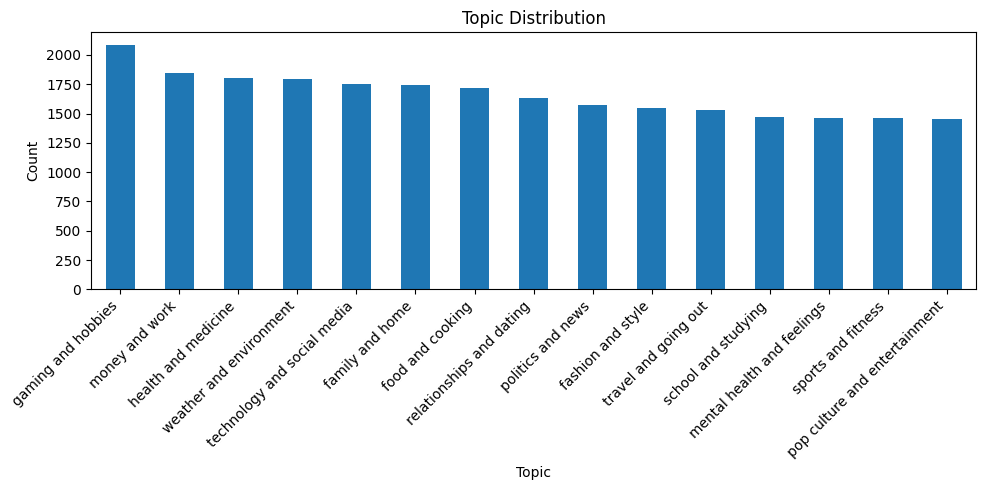

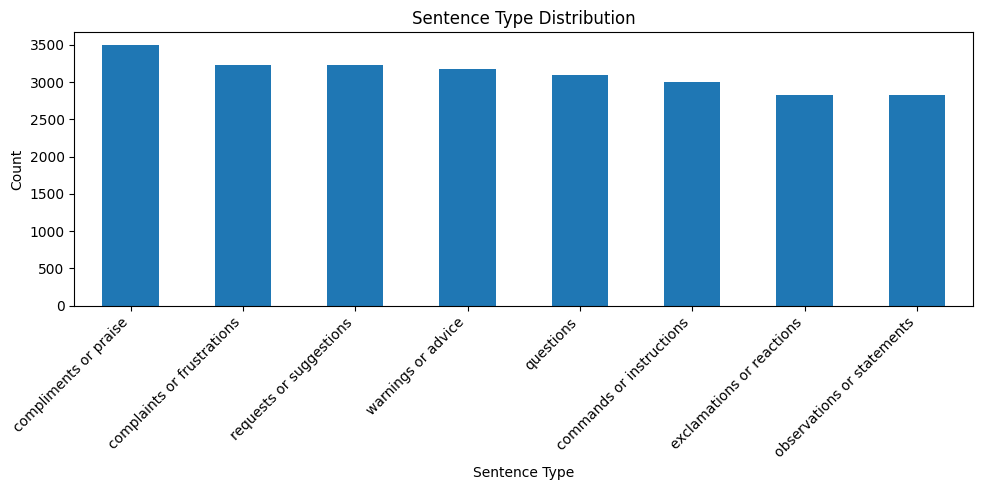

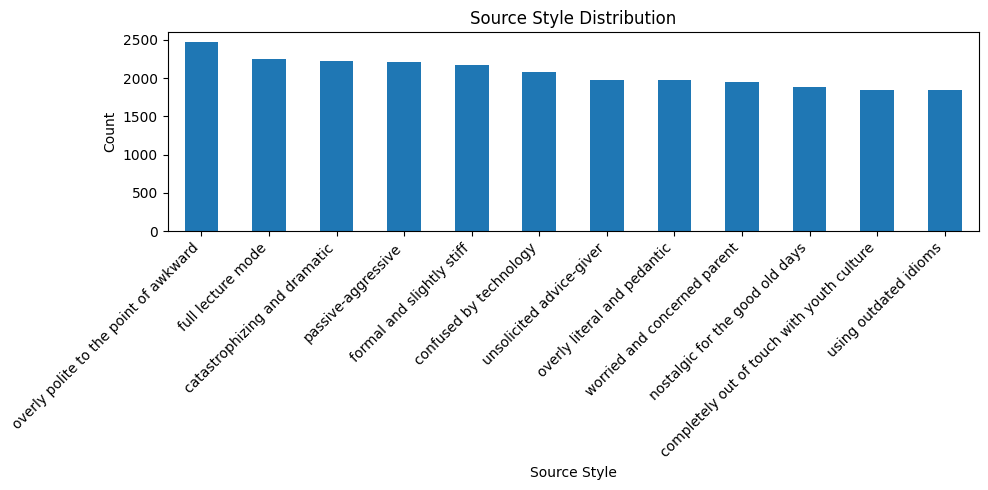

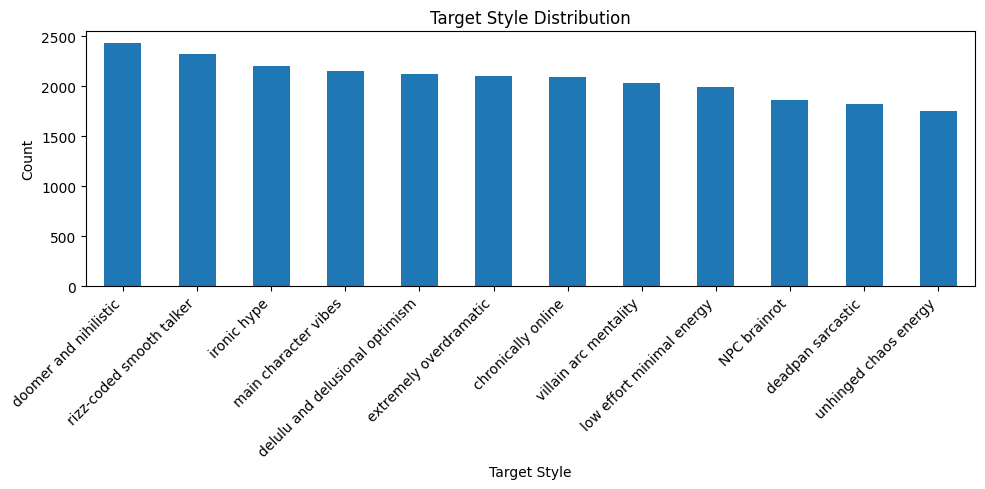

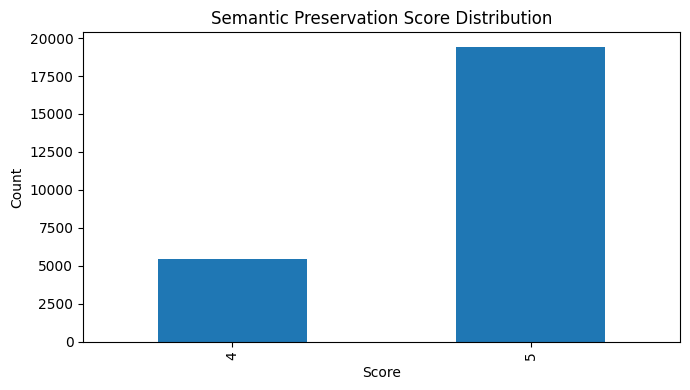

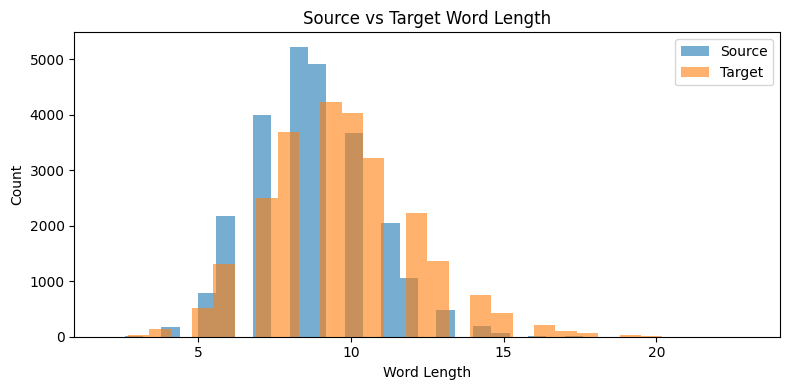

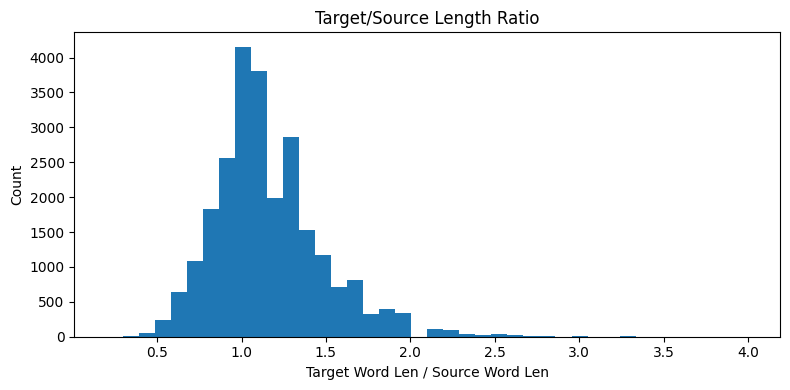

In [6]:
def bar_plot_counts(series, title, xlabel, ylabel="Count", top_n=None, rotation=45):
    counts = series.value_counts()
    if top_n is not None:
        counts = counts.head(top_n)
    plt.figure(figsize=(10, 5))
    counts.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()

bar_plot_counts(df["topic"], "Topic Distribution", "Topic")
bar_plot_counts(df["sentence_type"], "Sentence Type Distribution", "Sentence Type")
bar_plot_counts(df["boomer_style"], "Source Style Distribution", "Source Style")
bar_plot_counts(df["gen_alpha_style"], "Target Style Distribution", "Target Style")

plt.figure(figsize=(7, 4))
df["semantic_preservation_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Semantic Preservation Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df["source_word_len"], bins=30, alpha=0.6, label="Source")
plt.hist(df["target_word_len"], bins=30, alpha=0.6, label="Target")
plt.title("Source vs Target Word Length")
plt.xlabel("Word Length")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df["target_source_length_ratio"].dropna(), bins=40)
plt.title("Target/Source Length Ratio")
plt.xlabel("Target Word Len / Source Word Len")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 7. Stratified Split

Split method: stratified
Train: (19908, 16)
Val: (2488, 16)
Test: (2489, 16)


,split,rows
0,train,19908
1,val,2488
2,test,2489


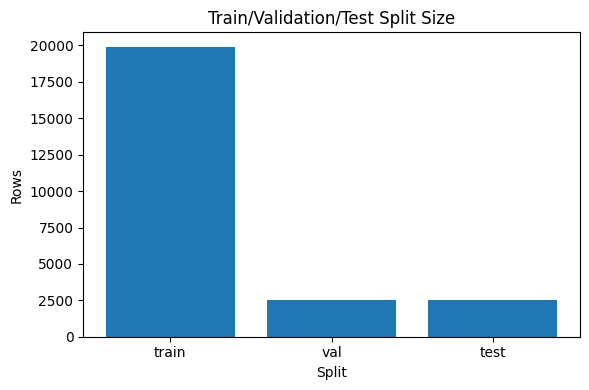

In [7]:
def make_stratify_label(frame):
    label = frame["topic"].astype(str) + " | " + frame["sentence_type"].astype(str)
    counts = label.value_counts()
    # Collapse rare combinations to avoid stratified split errors.
    label = label.where(label.map(counts) >= 3, "RARE_COMBO")
    return label

df["stratify_label"] = make_stratify_label(df)

try:
    train_df, temp_df = train_test_split(
        df,
        test_size=(1 - TRAIN_SIZE),
        random_state=SEED,
        stratify=df["stratify_label"],
    )

    temp_stratify = make_stratify_label(temp_df)
    val_fraction_of_temp = VAL_SIZE / (VAL_SIZE + TEST_SIZE)

    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1 - val_fraction_of_temp),
        random_state=SEED,
        stratify=temp_stratify,
    )
    split_method = "stratified"

except ValueError as e:
    print("Stratified split failed, falling back to random split.")
    print("Reason:", e)
    train_df, temp_df = train_test_split(
        df,
        test_size=(1 - TRAIN_SIZE),
        random_state=SEED,
        shuffle=True,
    )
    val_fraction_of_temp = VAL_SIZE / (VAL_SIZE + TEST_SIZE)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1 - val_fraction_of_temp),
        random_state=SEED,
        shuffle=True,
    )
    split_method = "random"

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Split method:", split_method)
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)]
})
display(split_summary)

plt.figure(figsize=(6, 4))
plt.bar(split_summary["split"], split_summary["rows"])
plt.title("Train/Validation/Test Split Size")
plt.xlabel("Split")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

# Save splits for reproducibility.
train_df.to_csv(SPLIT_DIR / "train_split.csv", index=False)
val_df.to_csv(SPLIT_DIR / "val_split.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test_split.csv", index=False)

#### 8. Split Distribution & Audit

,train,val,test
topic,,,
family and home,0.070223,0.069936,0.069908
fashion and style,0.062287,0.061897,0.061872
food and cooking,0.068917,0.068730,0.069104
gaming and hobbies,0.083886,0.083601,0.084371
health and medicine,0.072584,0.072749,0.072720
mental health and feelings,0.058921,0.058682,0.059060
money and work,0.074242,0.074759,0.074327
politics and news,0.063191,0.062701,0.063479
pop culture and entertainment,0.058318,0.059084,0.058256


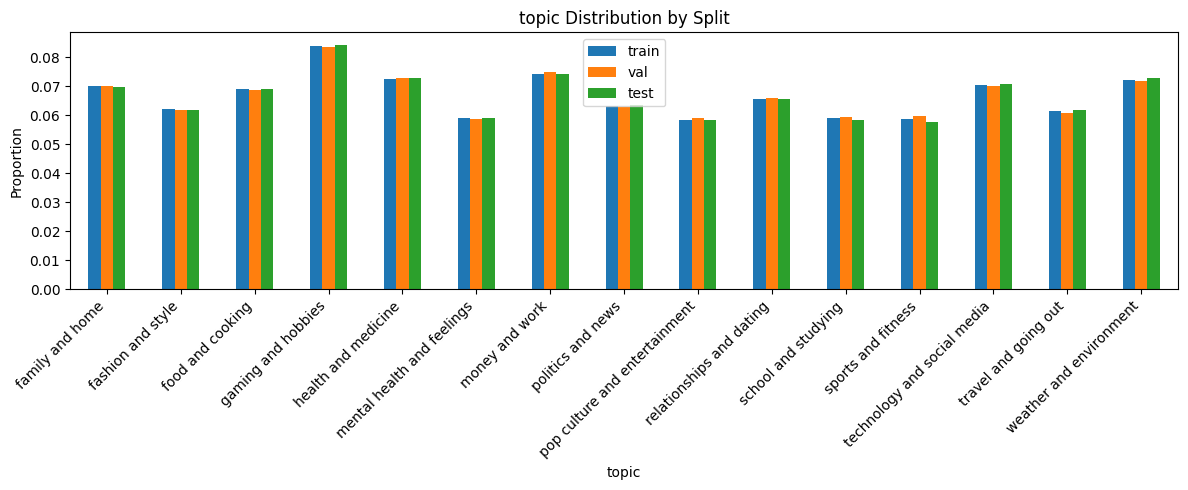

,train,val,test
sentence_type,,,
commands or instructions,0.120806,0.120981,0.120530
complaints or frustrations,0.129948,0.129823,0.130575
compliments or praise,0.140346,0.139469,0.141020
exclamations or reactions,0.113723,0.114148,0.112495
observations or statements,0.113723,0.113746,0.112897
questions,0.124422,0.124196,0.124548
requests or suggestions,0.129596,0.129823,0.129771
warnings or advice,0.127436,0.127814,0.128164


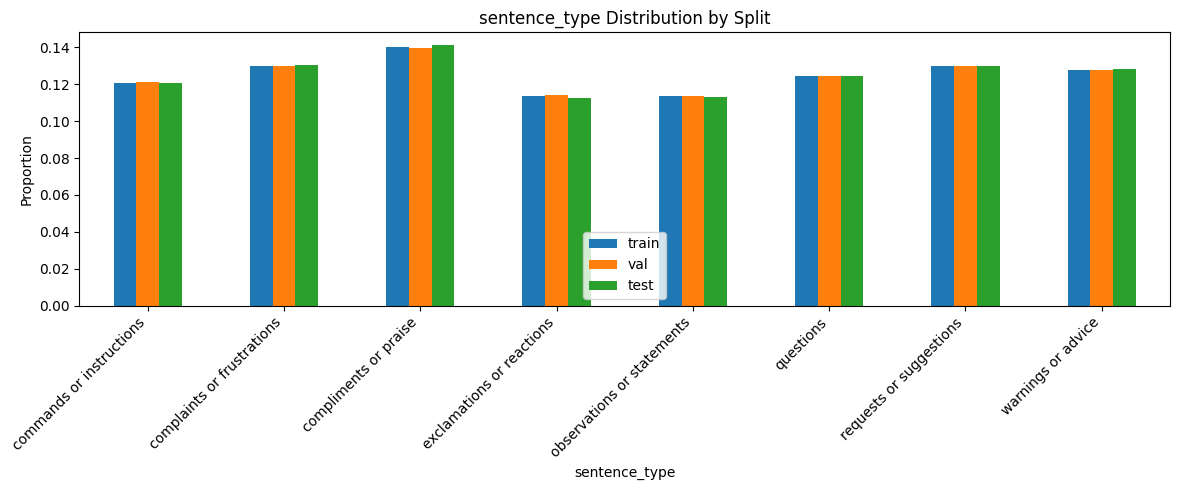

Full near-dup audit train-val boomer:   0%|          | 0/2488 [00:00<?, ?it/s]

Full near-dup audit train-test boomer:   0%|          | 0/2489 [00:00<?, ?it/s]

Full near-dup audit train-val gen_alpha:   0%|          | 0/2488 [00:00<?, ?it/s]

Full near-dup audit train-test gen_alpha:   0%|          | 0/2489 [00:00<?, ?it/s]

{
  "exact_train_val_source_overlap": 0,
  "exact_train_test_source_overlap": 0,
  "exact_val_test_source_overlap": 0,
  "exact_train_val_target_overlap": 4,
  "exact_train_test_target_overlap": 7,
  "exact_val_test_target_overlap": 0,
  "full_exact_normalized_overlap_rows": 11,
  "sampled_near_duplicate_examples_count": 0,
  "full_near_duplicate_examples_count": 21,
  "full_near_duplicate_threshold": 0.96
}
Exact normalized source/target overlaps found. Inspect the saved CSV:
/content/drive/MyDrive/NLP_Final_25K_Experiments/enhanced25k_20260523_100201/02_audits/full_exact_normalized_source_target_overlap.csv


,column,left_split,right_split,original_id_train,boomer_train,normalized_text,original_id_val,boomer_val,original_id_test,boomer_test,gen_alpha_train,gen_alpha_val,gen_alpha_test
0,gen_alpha,train,val,19578.0,NaN,make sure you put on a jacket if it s cold out,4235.0,NaN,NaN,NaN,Make sure you put on a jacket if it's cold out.,Make sure you put on a jacket if it's cold out.,NaN
1,gen_alpha,train,val,11536.0,NaN,you gotta watch how you re spending your money,21290.0,NaN,NaN,NaN,You gotta watch how you're spending your money.,You gotta watch how you're spending your money.,NaN
2,gen_alpha,train,val,8439.0,NaN,you pick things up super fast,8466.0,NaN,NaN,NaN,You pick things up super fast.,You pick things up super fast.,NaN
3,gen_alpha,train,val,18987.0,NaN,you gotta get better at managing your time,22098.0,NaN,NaN,NaN,You gotta get better at managing your time.,You gotta get better at managing your time.,NaN
4,gen_alpha,train,test,10615.0,NaN,make sure your outfit fits the place you re go...,NaN,NaN,10777.0,NaN,Make sure your outfit fits the place you're go...,NaN,Make sure your outfit fits the place you're go...
5,gen_alpha,train,test,20360.0,NaN,don t jump into a relationship too fast,NaN,NaN,17948.0,NaN,Don't jump into a relationship too fast.,NaN,Don't jump into a relationship too fast.
6,gen_alpha,train,test,9815.0,NaN,you should really appreciate what your parents...,NaN,NaN,3810.0,NaN,You should really appreciate what your parents...,NaN,You should really appreciate what your parents...
7,gen_alpha,train,test,22060.0,NaN,don t smoke it s bad for you,NaN,NaN,3037.0,NaN,"Don't smoke, it's bad for you.",NaN,"Don't smoke, it's bad for you."
8,gen_alpha,train,test,15990.0,NaN,tell someone where you re going duh,NaN,NaN,10679.0,NaN,"Tell someone where you're going, duh.",NaN,"Tell someone where you're going, duh."
9,gen_alpha,train,test,9391.0,NaN,being involved in politics is a must,NaN,NaN,9365.0,NaN,Being involved in politics is a must.,NaN,Being involved in politics is a must.


No sampled near-duplicate examples found, or sampled near-duplicate audit disabled.


,base_split,other_split,column,similarity,base_original_id,other_original_id,base_text,other_text
0,train,val,boomer,0.989691,6354,6370,Seek help if you're struggling with the material.,Seek help if you are struggling with the mater...
1,train,val,boomer,0.964912,9684,4195,I wish you’d show more gratitude for what we d...,I wish you would show more gratitude for what ...
2,train,val,boomer,0.977778,8439,8466,You're a quick learner.,You are a quick learner.
3,train,test,boomer,0.967033,24864,15575,You should not waste your time on distractions.,You shouldn’t waste your time on distractions.
4,train,test,boomer,0.988506,13851,13970,Don’t forget to hydrate during your workouts!,Don't forget to hydrate during your workout.
5,train,test,boomer,0.989691,13653,4279,I hope you realize how much we sacrificed for ...,I hope you realize how much we sacrifice for you.
6,train,test,boomer,0.962264,16162,23205,Have you thought about how this affects your f...,Have you thought about how this job affects yo...
7,train,val,gen_alpha,1.000000,19578,4235,Make sure you put on a jacket if it's cold out.,Make sure you put on a jacket if it's cold out.
8,train,val,gen_alpha,1.000000,18987,22098,You gotta get better at managing your time.,You gotta get better at managing your time.
9,train,val,gen_alpha,1.000000,11536,21290,You gotta watch how you're spending your money.,You gotta watch how you're spending your money.


In [8]:
def compare_split_distribution(col):
    rows = []
    for split_name, frame in [("train", train_df), ("val", val_df), ("test", test_df)]:
        props = frame[col].value_counts(normalize=True).rename(split_name)
        rows.append(props)
    comp = pd.concat(rows, axis=1).fillna(0).sort_index()
    return comp

for col in ["topic", "sentence_type"]:
    comp = compare_split_distribution(col)
    display(comp.head(20))

    # Save the exact table shown in the notebook so the Drive folder contains the numeric audit too.
    comp.to_csv(AUDIT_DIR / f"split_distribution_{col}.csv")

    ax = comp.plot(kind="bar", figsize=(12, 5))
    ax.set_title(f"{col} Distribution by Split")
    ax.set_xlabel(col)
    ax.set_ylabel("Proportion")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def exact_overlap_rows(left_df, right_df, col, left_name, right_name):
    """Return every exact normalized text overlap between two splits for one column."""
    left_tmp = left_df[["original_id", col]].copy()
    right_tmp = right_df[["original_id", col]].copy()
    left_tmp["normalized_text"] = left_tmp[col].apply(normalized_for_match)
    right_tmp["normalized_text"] = right_tmp[col].apply(normalized_for_match)

    # Empty normalized strings are not meaningful leakage signals.
    left_tmp = left_tmp[left_tmp["normalized_text"].str.len() > 0]
    right_tmp = right_tmp[right_tmp["normalized_text"].str.len() > 0]

    overlaps = left_tmp.merge(
        right_tmp,
        on="normalized_text",
        how="inner",
        suffixes=(f"_{left_name}", f"_{right_name}"),
    )
    overlaps.insert(0, "column", col)
    overlaps.insert(1, "left_split", left_name)
    overlaps.insert(2, "right_split", right_name)
    return overlaps

def exact_overlap_report(left_df, right_df, col):
    return int(len(exact_overlap_rows(left_df, right_df, col, "left", "right")))

# Full exact normalized source/target overlap, not sampled.
exact_overlap_frames = []
for col in [SOURCE_COL, TARGET_COL]:
    exact_overlap_frames.append(exact_overlap_rows(train_df, val_df, col, "train", "val"))
    exact_overlap_frames.append(exact_overlap_rows(train_df, test_df, col, "train", "test"))
    exact_overlap_frames.append(exact_overlap_rows(val_df, test_df, col, "val", "test"))

exact_overlap_df = pd.concat(exact_overlap_frames, ignore_index=True) if exact_overlap_frames else pd.DataFrame()
exact_overlap_df.to_csv(AUDIT_DIR / "full_exact_normalized_source_target_overlap.csv", index=False)

leakage_audit = {
    "exact_train_val_source_overlap": exact_overlap_report(train_df, val_df, SOURCE_COL),
    "exact_train_test_source_overlap": exact_overlap_report(train_df, test_df, SOURCE_COL),
    "exact_val_test_source_overlap": exact_overlap_report(val_df, test_df, SOURCE_COL),
    "exact_train_val_target_overlap": exact_overlap_report(train_df, val_df, TARGET_COL),
    "exact_train_test_target_overlap": exact_overlap_report(train_df, test_df, TARGET_COL),
    "exact_val_test_target_overlap": exact_overlap_report(val_df, test_df, TARGET_COL),
}

def char_ngrams(text, n=5):
    text = normalized_for_match(text)
    if len(text) <= n:
        return {text} if text else set()
    return {text[i:i+n] for i in range(len(text)-n+1)}

def build_ngram_index(frame, col, n=5):
    """Build a char-ngram inverted index for one split/column."""
    norm_texts = frame[col].apply(normalized_for_match).tolist()
    inv = defaultdict(list)
    for i, text in enumerate(norm_texts):
        for ng in char_ngrams(text, n=n):
            inv[ng].append(i)
    return norm_texts, inv

def full_near_duplicate_audit(base_frame, other_frame, col, base_name, other_name, max_examples=50):
    """
    Full audit over every row in other_frame against indexed candidates from base_frame.
    This is not a random sample. The n-gram index avoids brute-force all-pair comparison.
    """
    if not RUN_FULL_NORMALIZED_OVERLAP_AUDIT:
        return []

    base_frame = base_frame.reset_index(drop=True)
    other_frame = other_frame.reset_index(drop=True)
    base_norm, inv = build_ngram_index(base_frame, col)

    examples = []
    for j, other_text_original in enumerate(tqdm(other_frame[col].tolist(), desc=f"Full near-dup audit {base_name}-{other_name} {col}")):
        other_norm = normalized_for_match(other_text_original)
        if not other_norm:
            continue

        candidate_counts = defaultdict(int)
        for ng in char_ngrams(other_norm):
            for i in inv.get(ng, []):
                candidate_counts[i] += 1

        candidates = sorted(candidate_counts, key=candidate_counts.get, reverse=True)[:NEAR_DUP_MAX_CANDIDATES_PER_ROW]

        for i in candidates:
            sim = SequenceMatcher(None, base_norm[i], other_norm).ratio()
            if sim >= FULL_NEAR_DUP_SEQUENCE_THRESHOLD:
                examples.append({
                    "base_split": base_name,
                    "other_split": other_name,
                    "column": col,
                    "similarity": float(sim),
                    "base_original_id": base_frame.loc[i, "original_id"],
                    "other_original_id": other_frame.loc[j, "original_id"],
                    "base_text": base_frame.loc[i, col],
                    "other_text": other_frame.loc[j, col],
                })
                break

        if len(examples) >= max_examples:
            break

    return examples

def sampled_near_duplicate_audit(train_frame, other_frame, col, other_name):
    if not RUN_NEAR_DUP_LEAKAGE_CHECK:
        return []

    train_sample = train_frame.sample(
        min(len(train_frame), NEAR_DUP_LEAKAGE_SAMPLE_PER_SPLIT),
        random_state=SEED
    ).reset_index(drop=True)
    other_sample = other_frame.sample(
        min(len(other_frame), NEAR_DUP_LEAKAGE_SAMPLE_PER_SPLIT),
        random_state=SEED + 1
    ).reset_index(drop=True)

    inv = defaultdict(list)
    train_norm = train_sample[col].apply(normalized_for_match).tolist()
    for i, text in enumerate(train_norm):
        for ng in list(char_ngrams(text))[:80]:
            inv[ng].append(i)

    examples = []
    for j, text in enumerate(other_sample[col].apply(normalized_for_match).tolist()):
        candidate_counts = defaultdict(int)
        for ng in list(char_ngrams(text))[:80]:
            for i in inv.get(ng, []):
                candidate_counts[i] += 1

        candidates = sorted(candidate_counts, key=candidate_counts.get, reverse=True)[:NEAR_DUP_MAX_CANDIDATES_PER_ROW]

        for i in candidates:
            sim = SequenceMatcher(None, train_norm[i], text).ratio()
            if sim >= NEAR_COPY_SEQUENCE_THRESHOLD:
                examples.append({
                    "other_split": other_name,
                    "column": col,
                    "similarity": float(sim),
                    "train_text": train_sample.loc[i, col],
                    "other_text": other_sample.loc[j, col],
                })
                break

        if len(examples) >= 10:
            break

    return examples

# Legacy sampled audit retained, now source + target.
sampled_near_examples = []
sampled_near_examples.extend(sampled_near_duplicate_audit(train_df, val_df, SOURCE_COL, "val_source"))
sampled_near_examples.extend(sampled_near_duplicate_audit(train_df, test_df, SOURCE_COL, "test_source"))
sampled_near_examples.extend(sampled_near_duplicate_audit(train_df, val_df, TARGET_COL, "val_target"))
sampled_near_examples.extend(sampled_near_duplicate_audit(train_df, test_df, TARGET_COL, "test_target"))

# Full near-duplicate audit: every val/test row checked against train, for source and target columns.
full_near_examples = []
full_near_examples.extend(full_near_duplicate_audit(train_df, val_df, SOURCE_COL, "train", "val", FULL_NEAR_DUP_MAX_EXAMPLES_PER_PAIR))
full_near_examples.extend(full_near_duplicate_audit(train_df, test_df, SOURCE_COL, "train", "test", FULL_NEAR_DUP_MAX_EXAMPLES_PER_PAIR))
full_near_examples.extend(full_near_duplicate_audit(train_df, val_df, TARGET_COL, "train", "val", FULL_NEAR_DUP_MAX_EXAMPLES_PER_PAIR))
full_near_examples.extend(full_near_duplicate_audit(train_df, test_df, TARGET_COL, "train", "test", FULL_NEAR_DUP_MAX_EXAMPLES_PER_PAIR))

leakage_audit["full_exact_normalized_overlap_rows"] = int(len(exact_overlap_df))
leakage_audit["sampled_near_duplicate_examples_count"] = int(len(sampled_near_examples))
leakage_audit["full_near_duplicate_examples_count"] = int(len(full_near_examples))
leakage_audit["full_near_duplicate_threshold"] = float(FULL_NEAR_DUP_SEQUENCE_THRESHOLD)

with open(AUDIT_DIR / "split_leakage_audit.json", "w") as f:
    json.dump(leakage_audit, f, indent=2)

print(json.dumps(leakage_audit, indent=2))

if len(exact_overlap_df) > 0:
    print("Exact normalized source/target overlaps found. Inspect the saved CSV:")
    print(AUDIT_DIR / "full_exact_normalized_source_target_overlap.csv")
    display(exact_overlap_df.head(20))
else:
    print("No exact normalized source/target overlap found across splits.")

if sampled_near_examples:
    sampled_near_df = pd.DataFrame(sampled_near_examples)
    sampled_near_df.to_csv(AUDIT_DIR / "sampled_near_duplicate_leakage_examples.csv", index=False)
    display(sampled_near_df)
else:
    print("No sampled near-duplicate examples found, or sampled near-duplicate audit disabled.")

if full_near_examples:
    full_near_df = pd.DataFrame(full_near_examples)
    full_near_df.to_csv(AUDIT_DIR / "full_near_duplicate_source_target_leakage_examples.csv", index=False)
    display(full_near_df.head(20))
else:
    print("No full near-duplicate examples found, or full near-duplicate audit disabled.")


#### 9. Prompt Formatting & HuggingFace Datasets

In [9]:
def build_prompt(row):
    source = normalize_spaces(row[SOURCE_COL])

    if not USE_CONDITIONAL_PROMPTING:
        return f"Rewrite into Gen Alpha style: {source}"

    return (
        "<genalpha> Rewrite into Gen Alpha style while preserving the original meaning, intention, "
        "and speaker attitude. Keep the same speech act: commands stay commands, advice stays advice, "
        "warnings stay warnings, praise stays praise, encouragement stays encouragement, questions stay questions, "
        "requests stay requests, complaints stay complaints, reactions stay reactions, and observations stay observations. "
        "Do not turn the sentence into a reply, contradiction, excuse, comeback, or emotional reaction. "
        f"| source: {source} "
        f"| target_style: {normalize_spaces(row['gen_alpha_style'])} "
        f"| topic: {normalize_spaces(row['topic'])} "
        f"| sentence_type: {normalize_spaces(row['sentence_type'])} "
        f"| source_style: {normalize_spaces(row['boomer_style'])}"
    )

def add_prompt_column(frame):
    frame = frame.copy()
    frame["prompt"] = frame.apply(build_prompt, axis=1)
    frame["target_text"] = frame[TARGET_COL].apply(normalize_spaces)
    return frame

train_raw = add_prompt_column(train_df)
val_raw = add_prompt_column(val_df)
test_raw = add_prompt_column(test_df)

print("Prompt preview:")
print(train_raw.loc[0, "prompt"])
print("Target preview:")
print(train_raw.loc[0, "target_text"])

hf_train_raw = Dataset.from_pandas(train_raw, preserve_index=False)
hf_val_raw = Dataset.from_pandas(val_raw, preserve_index=False)
hf_test_raw = Dataset.from_pandas(test_raw, preserve_index=False)

Prompt preview:
<genalpha> Rewrite into Gen Alpha style while preserving the original meaning, intention, and speaker attitude. Keep the same speech act: commands stay commands, advice stays advice, warnings stay warnings, praise stays praise, encouragement stays encouragement, questions stay questions, requests stay requests, complaints stay complaints, reactions stay reactions, and observations stay observations. Do not turn the sentence into a reply, contradiction, excuse, comeback, or emotional reaction. | source: You should probably consider a side hustle to make ends meet. | target_style: main character vibes | topic: money and work | sentence_type: requests or suggestions | source_style: passive-aggressive
Target preview:
Maybe get a side gig to help with bills?


#### 10. Metrics & Helpers

In [10]:
rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("sacrebleu")
meteor_metric = evaluate.load("meteor")
chrf_metric = CHRF()

def safe_mean(values):
    values = [v for v in values if v is not None and not (isinstance(v, float) and math.isnan(v))]
    return float(np.mean(values)) if values else 0.0

def token_f1(pred, ref):
    pred_tokens = normalized_for_match(pred).split()
    ref_tokens = normalized_for_match(ref).split()

    if not pred_tokens and not ref_tokens:
        return 1.0
    if not pred_tokens or not ref_tokens:
        return 0.0

    pred_counts = defaultdict(int)
    ref_counts = defaultdict(int)

    for t in pred_tokens:
        pred_counts[t] += 1
    for t in ref_tokens:
        ref_counts[t] += 1

    overlap = sum(min(pred_counts[t], ref_counts[t]) for t in pred_counts)
    precision = overlap / max(len(pred_tokens), 1)
    recall = overlap / max(len(ref_tokens), 1)

    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def compute_generation_metrics(preds, refs):
    preds = [normalize_spaces(p) for p in preds]
    refs = [normalize_spaces(r) for r in refs]

    rouge = rouge_metric.compute(predictions=preds, references=refs)
    bleu = bleu_metric.compute(predictions=preds, references=[[r] for r in refs])
    meteor = meteor_metric.compute(predictions=preds, references=refs)
    chrf = chrf_metric.corpus_score(preds, [refs]).score

    token_f1_scores = [token_f1(p, r) for p, r in zip(preds, refs)]
    exact_match = [int(normalized_for_match(p) == normalized_for_match(r)) for p, r in zip(preds, refs)]
    seq_sim = [sequence_similarity(p, r) for p, r in zip(preds, refs)]

    metrics = {
        "bleu": float(bleu["score"]),
        "chrf": float(chrf),
        "meteor": float(meteor["meteor"]),
        "rouge1": float(rouge["rouge1"]),
        "rouge2": float(rouge["rouge2"]),
        "rougeL": float(rouge["rougeL"]),
        "token_f1": safe_mean(token_f1_scores),
        "exact_match": safe_mean(exact_match),
        "sequence_similarity": safe_mean(seq_sim),
    }

    # Balanced validation selection metric.
    metrics["composite_score"] = (
        0.20 * metrics["bleu"] / 100.0 +
        0.20 * metrics["chrf"] / 100.0 +
        0.20 * metrics["meteor"] +
        0.20 * metrics["rougeL"] +
        0.20 * metrics["token_f1"]
    )

    return metrics

def generate_predictions(model, tokenizer, eval_frame, model_name, sample_size=EVAL_GENERATION_SAMPLE_SIZE):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    if sample_size is not None and len(eval_frame) > sample_size:
        work_df = eval_frame.sample(sample_size, random_state=SEED).reset_index(drop=True)
    else:
        work_df = eval_frame.reset_index(drop=True).copy()

    prompts = work_df["prompt"].tolist()
    refs = work_df["target_text"].tolist()
    preds = []

    batch_size = GENERATION_BATCH_SIZE_BY_VARIANT.get(model_name, 32)

    for start in tqdm(range(0, len(prompts), batch_size), desc=f"Generating {model_name}"):
        batch_prompts = prompts[start:start + batch_size]

        enc = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_INPUT_LENGTH,
        ).to(device)

        with torch.no_grad():
            generated = model.generate(
                **enc,
                max_new_tokens=GENERATION_MAX_NEW_TOKENS,
                num_beams=GENERATION_NUM_BEAMS,
                early_stopping=True,
            )

        decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)
        preds.extend([normalize_spaces(x) for x in decoded])

    return preds, refs, work_df

def plot_training_loss(log_history, title):
    train_steps = []
    train_losses = []
    eval_steps = []
    eval_losses = []

    for row in log_history:
        if "loss" in row:
            train_steps.append(row.get("step", len(train_steps)))
            train_losses.append(row["loss"])
        if "eval_loss" in row:
            eval_steps.append(row.get("step", len(eval_steps)))
            eval_losses.append(row["eval_loss"])

    plt.figure(figsize=(8, 4))
    if train_losses:
        plt.plot(train_steps, train_losses, label="train loss")
    if eval_losses:
        plt.plot(eval_steps, eval_losses, marker="o", label="eval loss")
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


#### 11. Training Function

In [11]:
def tokenize_dataset(raw_dataset, tokenizer, desc):
    def preprocess(batch):
        model_inputs = tokenizer(
            batch["prompt"],
            max_length=MAX_INPUT_LENGTH,
            truncation=True,
            padding=False,
        )

        labels = tokenizer(
            text_target=batch["target_text"],
            max_length=MAX_TARGET_LENGTH,
            truncation=True,
            padding=False,
        )

        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    remove_cols = raw_dataset.column_names
    return raw_dataset.map(
        preprocess,
        batched=True,
        remove_columns=remove_cols,
        desc=desc,
    )

def make_training_args(kwargs):
    # Some Transformers versions use evaluation_strategy, newer ones also expose eval_strategy.
    import inspect
    sig = inspect.signature(Seq2SeqTrainingArguments.__init__)
    params = set(sig.parameters.keys())

    if "evaluation_strategy" in params:
        kwargs["evaluation_strategy"] = "epoch"
    elif "eval_strategy" in params:
        kwargs["eval_strategy"] = "epoch"

    if "save_strategy" in params:
        kwargs["save_strategy"] = "epoch"

    if "predict_with_generate" in params:
        kwargs["predict_with_generate"] = False

    return Seq2SeqTrainingArguments(**kwargs)

def build_trainer(model, tokenizer, training_args, train_ds, val_ds, data_collator):
    trainer_kwargs = dict(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
        compute_metrics=None,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=EARLY_STOPPING_PATIENCE
            )
        ],
    )

    try:
        trainer = Seq2SeqTrainer(
            **trainer_kwargs,
            processing_class=tokenizer,
        )
        print("Trainer initialized with processing_class=tokenizer")
    except TypeError as e:
        if "processing_class" in str(e):
            trainer = Seq2SeqTrainer(
                **trainer_kwargs,
                tokenizer=tokenizer,
            )
            print("Trainer initialized with tokenizer=tokenizer")
        else:
            raise

    return trainer

def train_one_variant(model_name):
    print("=" * 80)
    print(f"Training: {model_name}")
    print("=" * 80)

    train_batch = BATCH_SIZE_BY_VARIANT.get(model_name, 32)
    eval_batch = GENERATION_BATCH_SIZE_BY_VARIANT.get(model_name, 32)
    grad_accum = GRADIENT_ACCUMULATION_BY_VARIANT.get(model_name, 1)

    print(f"Train batch: {train_batch} | Eval batch: {eval_batch} | Grad accum: {grad_accum}")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    # Ensure pad token exists.
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Prompt length audit on sample.
    sample_prompts = train_raw["prompt"].sample(min(200, len(train_raw)), random_state=SEED).tolist()
    prompt_lengths = [
        len(tokenizer(p, truncation=False)["input_ids"])
        for p in sample_prompts
    ]
    too_long = sum(x > MAX_INPUT_LENGTH for x in prompt_lengths)
    print(
        f"Prompt truncation audit: {too_long}/{len(prompt_lengths)} "
        f"({too_long / max(len(prompt_lengths), 1):.1%}) exceed {MAX_INPUT_LENGTH}; "
        f"avg={np.mean(prompt_lengths):.1f}, max={np.max(prompt_lengths)}"
    )

    train_ds = tokenize_dataset(hf_train_raw, tokenizer, f"Tokenizing train {model_name}")
    val_ds = tokenize_dataset(hf_val_raw, tokenizer, f"Tokenizing val {model_name}")

    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
        label_pad_token_id=-100,
        pad_to_multiple_of=8 if torch.cuda.is_available() else None,
    )

    safe_model_name = model_name.replace("/", "_")
    model_output_dir = CHECKPOINT_DIR / f"model_{safe_model_name}"

    training_kwargs = dict(
        output_dir=str(model_output_dir),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=train_batch,
        per_device_eval_batch_size=eval_batch,
        gradient_accumulation_steps=grad_accum,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        logging_steps=LOGGING_STEPS,
        save_total_limit=SAVE_TOTAL_LIMIT,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to=[],
        seed=SEED,
        data_seed=SEED,
        bf16=USE_BF16,
        fp16=USE_FP16,
    )

    training_args = make_training_args(training_kwargs)

    trainer = build_trainer(
        model=model,
        tokenizer=tokenizer,
        training_args=training_args,
        train_ds=train_ds,
        val_ds=val_ds,
        data_collator=data_collator,
    )

    train_result = trainer.train()
    eval_loss_metrics = trainer.evaluate()

    # Save raw trainer log history for reproducibility.
    log_history_path = LOG_DIR / f"trainer_log_history_{safe_model_name}.json"
    with open(log_history_path, "w") as f:
        json.dump(trainer.state.log_history, f, indent=2)

    plot_training_loss(trainer.state.log_history, f"Loss Progression — {model_name}")

    # Save best model.
    best_dir = BEST_MODEL_DIR / f"best_{safe_model_name}"
    trainer.save_model(str(best_dir))
    tokenizer.save_pretrained(str(best_dir))

    # Validation generation metrics for model selection.
    preds, refs, val_eval_df = generate_predictions(
        model=trainer.model,
        tokenizer=tokenizer,
        eval_frame=val_raw,
        model_name=model_name,
        sample_size=EVAL_GENERATION_SAMPLE_SIZE,
    )

    gen_metrics = compute_generation_metrics(preds, refs)

    # Save predictions.
    pred_df = val_eval_df.copy()
    pred_df["prediction"] = preds
    pred_df["reference"] = refs
    pred_df.to_csv(PREDICTION_DIR / f"val_predictions_{safe_model_name}.csv", index=False)

    record = {
        "model_name": model_name,
        "best_model_dir": str(best_dir),
        "train_batch_size": train_batch,
        "eval_batch_size": eval_batch,
        "grad_accum": grad_accum,
        "train_runtime": train_result.metrics.get("train_runtime"),
        "train_samples_per_second": train_result.metrics.get("train_samples_per_second"),
        "eval_loss": eval_loss_metrics.get("eval_loss"),
        **gen_metrics,
    }

    # Clean up VRAM.
    del trainer
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return record

#### 12. Run Experiment

Training: t5-small
Train batch: 64 | Eval batch: 64 | Grad accum: 1


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Tokenizing train t5-small:   0%|          | 0/19908 [00:00<?, ? examples/s]

Tokenizing val t5-small:   0%|          | 0/2488 [00:00<?, ? examples/s]

Trainer initialized with processing_class=tokenizer


Epoch,Training Loss,Validation Loss
1,2.468500,2.243415
2,2.342900,2.112026
3,2.257200,2.039346
4,2.184200,1.990499
5,2.152300,1.957754
6,2.118700,1.930902
7,2.105500,1.912649
8,2.078700,1.897253
9,2.050900,1.884080
10,2.026600,1.875446


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


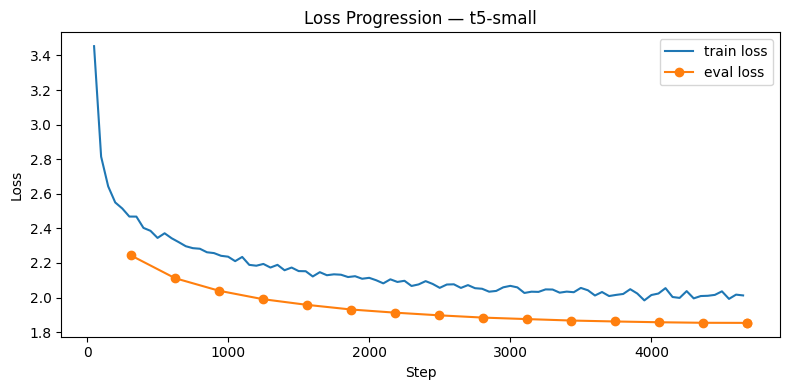

Generating t5-small:   0%|          | 0/39 [00:00<?, ?it/s]

,model_name,best_model_dir,train_batch_size,eval_batch_size,grad_accum,train_runtime,train_samples_per_second,eval_loss,bleu,chrf,meteor,rouge1,rouge2,rougeL,token_f1,exact_match,sequence_similarity,composite_score
0,t5-small,/content/drive/MyDrive/NLP_Final_25K_Experimen...,64,64,1,216.1897,1381.287,1.853529,15.189036,39.113154,0.430812,0.439335,0.240172,0.416883,0.439348,0.00201,0.564749,0.366013


Training: google/flan-t5-small
Train batch: 64 | Eval batch: 64 | Grad accum: 1


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

Tokenizing train google/flan-t5-small:   0%|          | 0/19908 [00:00<?, ? examples/s]

Tokenizing val google/flan-t5-small:   0%|          | 0/2488 [00:00<?, ? examples/s]

Trainer initialized with processing_class=tokenizer


Epoch,Training Loss,Validation Loss
1,2.326200,2.059669
2,2.191500,1.950494
3,2.117000,1.885834
4,2.048400,1.841539
5,2.006900,1.812988
6,1.972900,1.789638
7,1.963200,1.771040
8,1.935400,1.756709
9,1.901200,1.744217
10,1.884700,1.736878


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


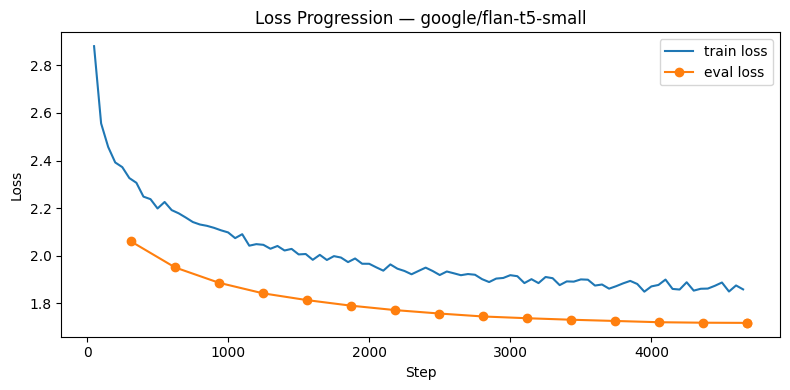

Generating google/flan-t5-small:   0%|          | 0/39 [00:00<?, ?it/s]

,model_name,best_model_dir,train_batch_size,eval_batch_size,grad_accum,train_runtime,train_samples_per_second,eval_loss,bleu,chrf,meteor,rouge1,rouge2,rougeL,token_f1,exact_match,sequence_similarity,composite_score
1,google/flan-t5-small,/content/drive/MyDrive/NLP_Final_25K_Experimen...,64,64,1,278.4750,1072.340,1.717315,15.227464,39.279177,0.433328,0.438897,0.240332,0.415749,0.438735,0.002412,0.564028,0.366576
0,t5-small,/content/drive/MyDrive/NLP_Final_25K_Experimen...,64,64,1,216.1897,1381.287,1.853529,15.189036,39.113154,0.430812,0.439335,0.240172,0.416883,0.439348,0.002010,0.564749,0.366013


Training: facebook/bart-base
Train batch: 32 | Eval batch: 32 | Grad accum: 2


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Tokenizing train facebook/bart-base:   0%|          | 0/19908 [00:00<?, ? examples/s]

Tokenizing val facebook/bart-base:   0%|          | 0/2488 [00:00<?, ? examples/s]

Trainer initialized with processing_class=tokenizer


Epoch,Training Loss,Validation Loss
1,1.706800,1.448608
2,1.517700,1.360213
3,1.385000,1.327758
4,1.291300,1.304455
5,1.215100,1.294261
6,1.158300,1.291495
7,1.101900,1.291071
8,1.059700,1.296082
9,0.998900,1.298539


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


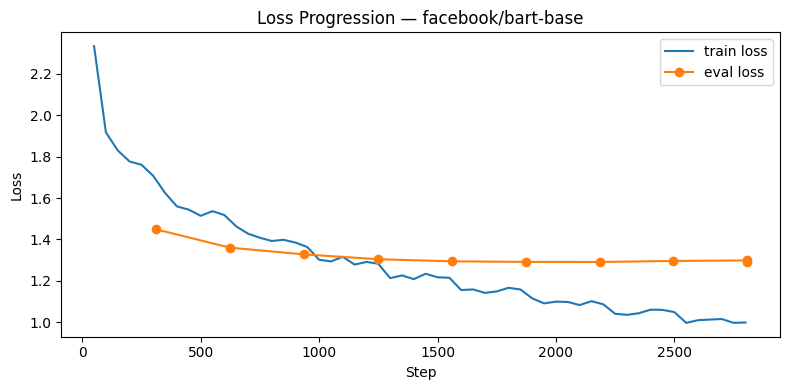

Generating facebook/bart-base:   0%|          | 0/78 [00:00<?, ?it/s]

,model_name,best_model_dir,train_batch_size,eval_batch_size,grad_accum,train_runtime,train_samples_per_second,eval_loss,bleu,chrf,meteor,rouge1,rouge2,rougeL,token_f1,exact_match,sequence_similarity,composite_score
2,facebook/bart-base,/content/drive/MyDrive/NLP_Final_25K_Experimen...,32,32,2,200.6904,1487.964,1.291071,19.445333,42.074678,0.470834,0.478366,0.283886,0.455140,0.478137,0.011254,0.593029,0.403862
1,google/flan-t5-small,/content/drive/MyDrive/NLP_Final_25K_Experimen...,64,64,1,278.4750,1072.340,1.717315,15.227464,39.279177,0.433328,0.438897,0.240332,0.415749,0.438735,0.002412,0.564028,0.366576
0,t5-small,/content/drive/MyDrive/NLP_Final_25K_Experimen...,64,64,1,216.1897,1381.287,1.853529,15.189036,39.113154,0.430812,0.439335,0.240172,0.416883,0.439348,0.002010,0.564749,0.366013


Training: t5-base
Train batch: 32 | Eval batch: 32 | Grad accum: 2


config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

Tokenizing train t5-base:   0%|          | 0/19908 [00:00<?, ? examples/s]

Tokenizing val t5-base:   0%|          | 0/2488 [00:00<?, ? examples/s]

Trainer initialized with processing_class=tokenizer


Epoch,Training Loss,Validation Loss
1,1.851700,1.647445
2,1.714600,1.544526
3,1.624100,1.488179
4,1.556800,1.455878
5,1.518200,1.429957
6,1.486200,1.416934
7,1.457300,1.402987
8,1.430700,1.392353
9,1.397900,1.386763
10,1.381900,1.381930


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


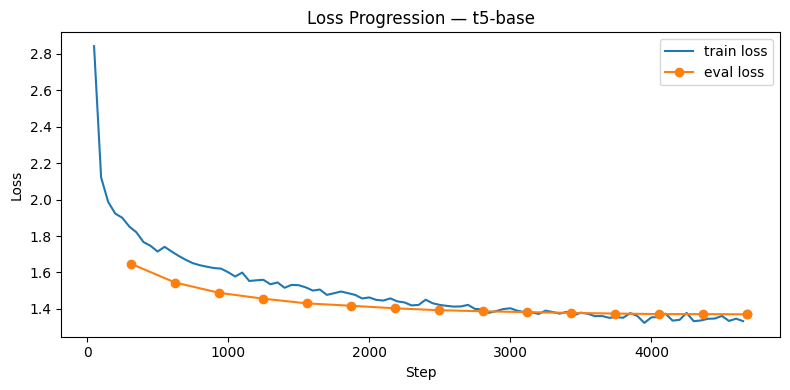

Generating t5-base:   0%|          | 0/78 [00:00<?, ?it/s]

,model_name,best_model_dir,train_batch_size,eval_batch_size,grad_accum,train_runtime,train_samples_per_second,eval_loss,bleu,chrf,meteor,rouge1,rouge2,rougeL,token_f1,exact_match,sequence_similarity,composite_score
2,facebook/bart-base,/content/drive/MyDrive/NLP_Final_25K_Experimen...,32,32,2,200.6904,1487.964,1.291071,19.445333,42.074678,0.470834,0.478366,0.283886,0.455140,0.478137,0.011254,0.593029,0.403862
3,t5-base,/content/drive/MyDrive/NLP_Final_25K_Experimen...,32,32,2,770.1104,387.763,1.369961,18.254744,41.582738,0.465424,0.469900,0.273261,0.445778,0.469681,0.006029,0.586189,0.395852
1,google/flan-t5-small,/content/drive/MyDrive/NLP_Final_25K_Experimen...,64,64,1,278.4750,1072.340,1.717315,15.227464,39.279177,0.433328,0.438897,0.240332,0.415749,0.438735,0.002412,0.564028,0.366576
0,t5-small,/content/drive/MyDrive/NLP_Final_25K_Experimen...,64,64,1,216.1897,1381.287,1.853529,15.189036,39.113154,0.430812,0.439335,0.240172,0.416883,0.439348,0.002010,0.564749,0.366013


Training: google/flan-t5-base
Train batch: 32 | Eval batch: 32 | Grad accum: 2


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

Tokenizing train google/flan-t5-base:   0%|          | 0/19908 [00:00<?, ? examples/s]

Tokenizing val google/flan-t5-base:   0%|          | 0/2488 [00:00<?, ? examples/s]

Trainer initialized with processing_class=tokenizer


Epoch,Training Loss,Validation Loss
1,1.881900,1.642548
2,1.748100,1.545500
3,1.665500,1.493378
4,1.596700,1.456489
5,1.562200,1.427801
6,1.523800,1.410913
7,1.508400,1.397888
8,1.474400,1.384838
9,1.446700,1.375692
10,1.424400,1.370355


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


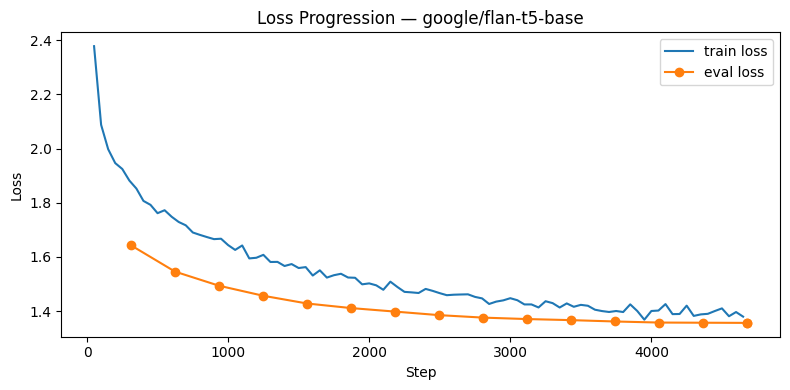

Generating google/flan-t5-base:   0%|          | 0/78 [00:00<?, ?it/s]

,model_name,best_model_dir,train_batch_size,eval_batch_size,grad_accum,train_runtime,train_samples_per_second,eval_loss,bleu,chrf,meteor,rouge1,rouge2,rougeL,token_f1,exact_match,sequence_similarity,composite_score
2,facebook/bart-base,/content/drive/MyDrive/NLP_Final_25K_Experimen...,32,32,2,200.6904,1487.964,1.291071,19.445333,42.074678,0.470834,0.478366,0.283886,0.455140,0.478137,0.011254,0.593029,0.403862
3,t5-base,/content/drive/MyDrive/NLP_Final_25K_Experimen...,32,32,2,770.1104,387.763,1.369961,18.254744,41.582738,0.465424,0.469900,0.273261,0.445778,0.469681,0.006029,0.586189,0.395852
4,google/flan-t5-base,/content/drive/MyDrive/NLP_Final_25K_Experimen...,32,32,2,975.5388,306.108,1.356240,18.036882,41.703722,0.468786,0.465289,0.269419,0.440869,0.465258,0.005627,0.584059,0.394464
1,google/flan-t5-small,/content/drive/MyDrive/NLP_Final_25K_Experimen...,64,64,1,278.4750,1072.340,1.717315,15.227464,39.279177,0.433328,0.438897,0.240332,0.415749,0.438735,0.002412,0.564028,0.366576
0,t5-small,/content/drive/MyDrive/NLP_Final_25K_Experimen...,64,64,1,216.1897,1381.287,1.853529,15.189036,39.113154,0.430812,0.439335,0.240172,0.416883,0.439348,0.002010,0.564749,0.366013


,model_name,best_model_dir,train_batch_size,eval_batch_size,grad_accum,train_runtime,train_samples_per_second,eval_loss,bleu,chrf,meteor,rouge1,rouge2,rougeL,token_f1,exact_match,sequence_similarity,composite_score
0,facebook/bart-base,/content/drive/MyDrive/NLP_Final_25K_Experimen...,32,32,2,200.6904,1487.964,1.291071,19.445333,42.074678,0.470834,0.478366,0.283886,0.455140,0.478137,0.011254,0.593029,0.403862
1,t5-base,/content/drive/MyDrive/NLP_Final_25K_Experimen...,32,32,2,770.1104,387.763,1.369961,18.254744,41.582738,0.465424,0.469900,0.273261,0.445778,0.469681,0.006029,0.586189,0.395852
2,google/flan-t5-base,/content/drive/MyDrive/NLP_Final_25K_Experimen...,32,32,2,975.5388,306.108,1.356240,18.036882,41.703722,0.468786,0.465289,0.269419,0.440869,0.465258,0.005627,0.584059,0.394464
3,google/flan-t5-small,/content/drive/MyDrive/NLP_Final_25K_Experimen...,64,64,1,278.4750,1072.340,1.717315,15.227464,39.279177,0.433328,0.438897,0.240332,0.415749,0.438735,0.002412,0.564028,0.366576
4,t5-small,/content/drive/MyDrive/NLP_Final_25K_Experimen...,64,64,1,216.1897,1381.287,1.853529,15.189036,39.113154,0.430812,0.439335,0.240172,0.416883,0.439348,0.002010,0.564749,0.366013


Best model selected using validation metric only:
{
  "model_name": "facebook/bart-base",
  "best_model_dir": "/content/drive/MyDrive/NLP_Final_25K_Experiments/enhanced25k_20260523_100201/06_best_models/best_facebook_bart-base",
  "train_batch_size": 32,
  "eval_batch_size": 32,
  "grad_accum": 2,
  "train_runtime": 200.6904,
  "train_samples_per_second": 1487.964,
  "eval_loss": 1.291070580482483,
  "bleu": 19.445332701442286,
  "chrf": 42.07467790294555,
  "meteor": 0.4708341180326518,
  "rouge1": 0.4783657990903731,
  "rouge2": 0.2838855551015672,
  "rougeL": 0.45514029151177293,
  "token_f1": 0.478136574953751,
  "exact_match": 0.011254019292604502,
  "sequence_similarity": 0.5930288719436047,
  "composite_score": 0.4038622181084109
}


In [12]:
variant_results = []

for model_name in MODEL_VARIANTS:
    try:
        result = train_one_variant(model_name)
        variant_results.append(result)

        results_df = pd.DataFrame(variant_results)
        results_df.to_csv(RESULTS_CSV_PATH, index=False)
        display(results_df.sort_values(SELECTION_METRIC, ascending=False))

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"CUDA OOM for {model_name}. Try reducing its batch size.")
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
        else:
            raise

results_df = pd.DataFrame(variant_results)
if len(results_df) == 0:
    raise RuntimeError("No model finished training successfully.")

results_df = results_df.sort_values(SELECTION_METRIC, ascending=False).reset_index(drop=True)
display(results_df)

best_record = results_df.iloc[0].to_dict()
print("Best model selected using validation metric only:")
print(json.dumps(best_record, indent=2))
with open(METRIC_DIR / "best_validation_model_record.json", "w") as f:
    json.dump(best_record, f, indent=2)


#### 13. Validation Result Visualization

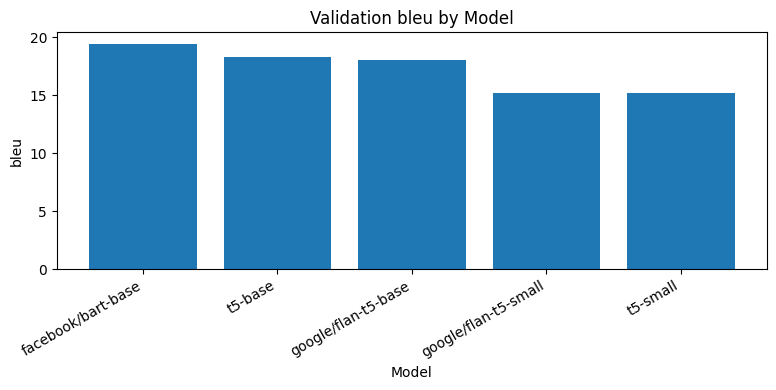

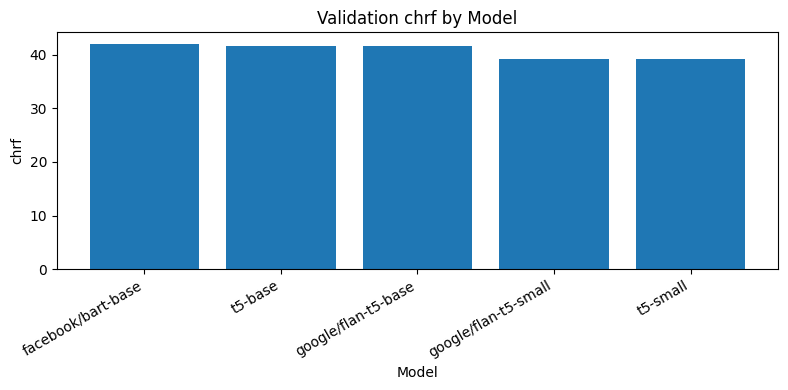

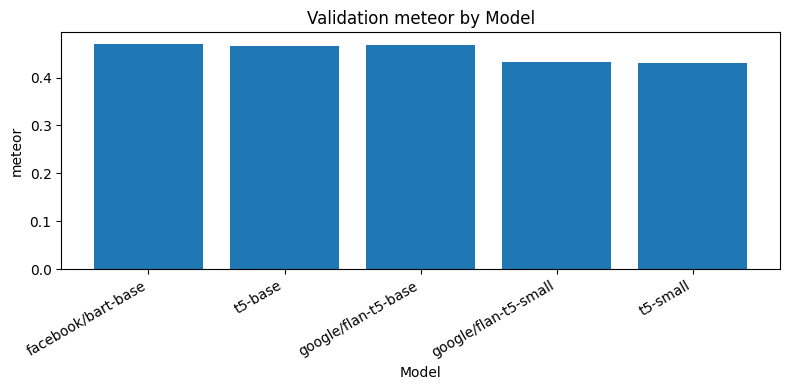

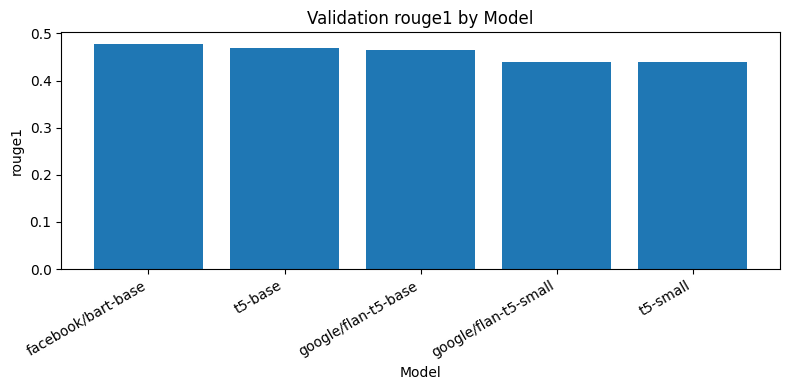

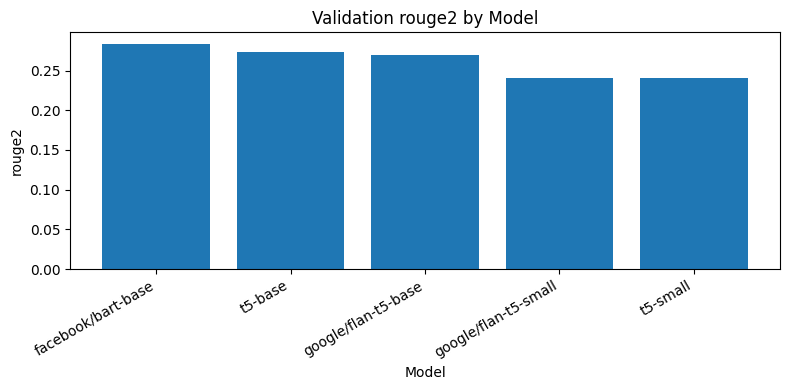

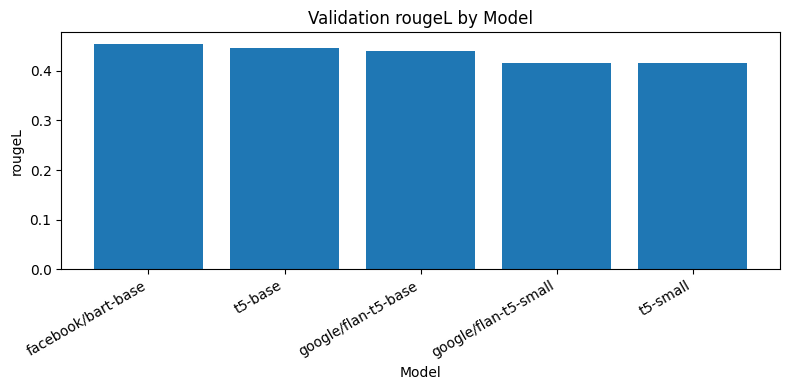

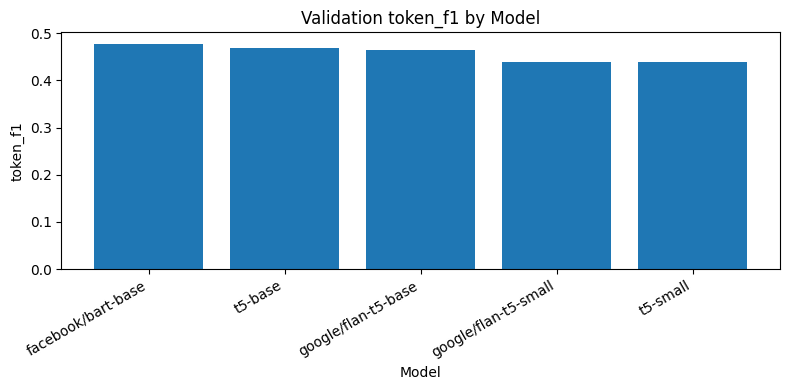

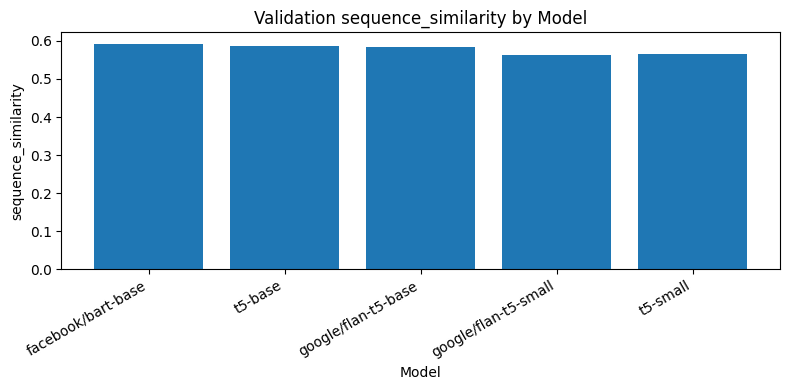

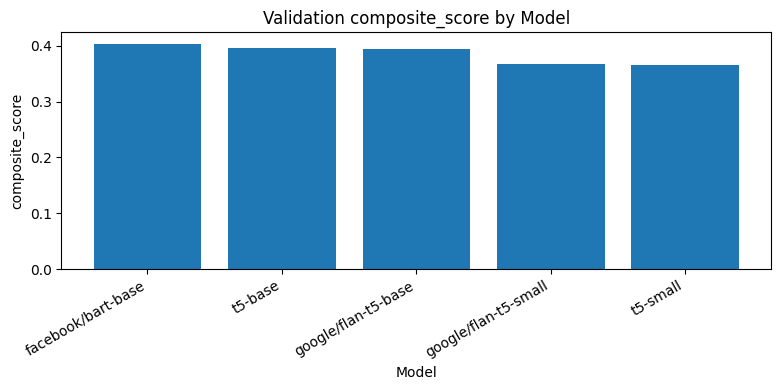

,model_name,bleu,chrf,meteor,rouge1,rouge2,rougeL,token_f1,sequence_similarity,composite_score
0,facebook/bart-base,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,t5-base,0.720276,0.833890,0.864826,0.785519,0.756954,0.762324,0.785400,0.764140,0.788354
2,google/flan-t5-base,0.669090,0.874742,0.948832,0.668684,0.669066,0.637708,0.673155,0.690711,0.751692
3,google/flan-t5-small,0.009029,0.056060,0.062877,0.000000,0.003663,0.000000,0.000000,0.000000,0.014870
4,t5-small,0.000000,0.000000,0.000000,0.011111,0.000000,0.028785,0.015557,0.024860,0.000000


In [13]:
metric_cols = [
    "bleu", "chrf", "meteor", "rouge1", "rouge2", "rougeL",
    "token_f1", "sequence_similarity", "composite_score"
]

plot_df = results_df[["model_name"] + [m for m in metric_cols if m in results_df.columns]].copy()
plot_df.to_csv(METRIC_DIR / "validation_metrics_plot_table.csv", index=False)

for metric in [m for m in metric_cols if m in plot_df.columns]:
    plt.figure(figsize=(8, 4))
    plt.bar(plot_df["model_name"], plot_df[metric])
    plt.title(f"Validation {metric} by Model")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Normalized heatmap-like table.
norm_df = plot_df.copy()
for metric in [m for m in metric_cols if m in norm_df.columns]:
    min_v = norm_df[metric].min()
    max_v = norm_df[metric].max()
    if max_v > min_v:
        norm_df[metric] = (norm_df[metric] - min_v) / (max_v - min_v)
    else:
        norm_df[metric] = 1.0

norm_df.to_csv(METRIC_DIR / "validation_metrics_normalized_table.csv", index=False)
display(norm_df)

#### 14. Final Evaluation of Best Model

In [14]:
best_model_name = best_record["model_name"]
best_model_dir = best_record["best_model_dir"]

print("Loading selected model:", best_model_name)
print("From:", best_model_dir)

tokenizer = AutoTokenizer.from_pretrained(best_model_dir)
model = AutoModelForSeq2SeqLM.from_pretrained(best_model_dir).to(DEVICE)

test_preds, test_refs, test_eval_df = generate_predictions(
    model=model,
    tokenizer=tokenizer,
    eval_frame=test_raw,
    model_name=best_model_name,
    sample_size=EVAL_GENERATION_SAMPLE_SIZE,
)

test_metrics = compute_generation_metrics(test_preds, test_refs)
test_metrics["selected_model"] = best_model_name
test_metrics["selected_model_dir"] = best_model_dir
test_metrics["test_rows_evaluated"] = len(test_refs)

with open(FINAL_TEST_JSON_PATH, "w") as f:
    json.dump(test_metrics, f, indent=2)

test_pred_df = test_eval_df.copy()
test_pred_df["prediction"] = test_preds
test_pred_df["reference"] = test_refs
test_pred_df.to_csv(PREDICTION_DIR / "final_test_predictions_selected_model.csv", index=False)

print(json.dumps(test_metrics, indent=2))
display(test_pred_df[[SOURCE_COL, TARGET_COL, "prediction", "topic", "sentence_type"]].head(20))

del model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

Loading selected model: facebook/bart-base
From: /content/drive/MyDrive/NLP_Final_25K_Experiments/enhanced25k_20260523_100201/06_best_models/best_facebook_bart-base


Generating facebook/bart-base:   0%|          | 0/78 [00:00<?, ?it/s]

{
  "bleu": 19.196478457219634,
  "chrf": 41.66907952231578,
  "meteor": 0.4611994745498016,
  "rouge1": 0.4694395598379522,
  "rouge2": 0.28025033101751406,
  "rougeL": 0.4463466439118189,
  "token_f1": 0.46952495780941017,
  "exact_match": 0.009642426677380474,
  "sequence_similarity": 0.5857214055152944,
  "composite_score": 0.39714533121327694,
  "selected_model": "facebook/bart-base",
  "selected_model_dir": "/content/drive/MyDrive/NLP_Final_25K_Experiments/enhanced25k_20260523_100201/06_best_models/best_facebook_bart-base",
  "test_rows_evaluated": 2489
}


,boomer,gen_alpha,prediction,topic,sentence_type
0,You should consider a wardrobe overhaul.,"My whole look is about to collapse and burn, j...",You should totally switch up your wardrobe.,fashion and style,exclamations or reactions
1,You should think about the future instead of w...,You should actually think about what's next in...,You should actually think about the future ins...,technology and social media,observations or statements
2,Collecting items in games can be a rewarding e...,Being a hardcore gamer and collecting in-game ...,Collecting stuff in games is a whole mood.,gaming and hobbies,observations or statements
3,You ought to cherish the memories you create o...,"Remember the stuff you do when you travel, I g...",You should really appreciate the memories you ...,travel and going out,compliments or praise
4,You seem to have a good handle on your gaming ...,"You're actually managing your game time well, ...",You seem to have a good handle on how much tim...,gaming and hobbies,compliments or praise
5,Emphasizing strength training is beneficial as...,Doing strength training is good for you as you...,Lifting weights is a good move as you get older.,sports and fitness,warnings or advice
6,I remember when the wildlife was more abundant.,I miss when there were way more animals around.,Wildlife used to be way more abundant back in ...,weather and environment,observations or statements
7,I sincerely hope you are taking this seriously.,Hope you're for real about this.,Hope you're actually taking this seriously.,health and medicine,exclamations or reactions
8,Public service is a noble profession.,Serving the public is a cool job.,Being a good citizen is a good thing.,politics and news,exclamations or reactions
9,Why not try to see things from their point of ...,Can you even comprehend trying to be on their ...,Why not try to see things from their point of ...,relationships and dating,questions


#### ONNX Export

In [15]:
# Optional ONNX export for the selected best model.
# Recommended for deployment/inference experiments, not required for training metrics.
RUN_ONNX_EXPORT = True

ONNX_DIR = OUTPUT_DIR / "10_onnx_export" / best_model_name.replace("/", "_")
ONNX_DIR.mkdir(parents=True, exist_ok=True)

if RUN_ONNX_EXPORT:
    print("Exporting selected model to ONNX:")
    print("Best model dir:", best_model_dir)
    print("ONNX output dir:", ONNX_DIR)

    try:
        from optimum.onnxruntime import ORTModelForSeq2SeqLM

        # export=True converts the local Transformers checkpoint into ONNX files.
        # For seq2seq models, Optimum normally exports separate encoder/decoder ONNX graphs.
        ort_model = ORTModelForSeq2SeqLM.from_pretrained(
            best_model_dir,
            export=True,
            provider="CPUExecutionProvider",
        )
        ort_model.save_pretrained(str(ONNX_DIR))
        tokenizer.save_pretrained(str(ONNX_DIR))

        onnx_files = sorted([p.name for p in ONNX_DIR.glob("*.onnx")])
        with open(ONNX_DIR / "onnx_export_manifest.json", "w") as f:
            json.dump(
                {
                    "source_model_dir": str(best_model_dir),
                    "onnx_dir": str(ONNX_DIR),
                    "onnx_files": onnx_files,
                    "export_method": "ORTModelForSeq2SeqLM.from_pretrained(export=True)",
                },
                f,
                indent=2,
            )

        print("ONNX export complete.")
        print("ONNX files:", onnx_files)

        # Quick smoke test: load ONNX model and generate one sample.
        ort_model = ORTModelForSeq2SeqLM.from_pretrained(str(ONNX_DIR), provider="CPUExecutionProvider")
        ort_model.eval()

        sample_text = "It is important to take a short break after studying for a long time."
        sample_prompt = build_prompt({
            SOURCE_COL: sample_text,
            "topic": "education",
            "boomer_style": "formal advice",
            "gen_alpha_style": "gen alpha casual",
            "sentence_type": "advice",
        })
        enc = tokenizer(sample_prompt, return_tensors="pt", truncation=True, max_length=MAX_INPUT_LENGTH)
        out = ort_model.generate(
            **enc,
            max_new_tokens=GENERATION_MAX_NEW_TOKENS,
            num_beams=GENERATION_NUM_BEAMS,
            early_stopping=True,
        )
        print("ONNX smoke-test output:", tokenizer.decode(out[0], skip_special_tokens=True))

    except Exception as e:
        print("ONNX export failed.")
        print("Reason:", repr(e))
        print("Alternative CLI command to run manually in a Colab cell:")
        print(f"!optimum-cli export onnx --model '{best_model_dir}' --task seq2seq-lm '{ONNX_DIR}'")
else:
    print("ONNX export disabled. Set RUN_ONNX_EXPORT = True to export.")

Exporting selected model to ONNX:
Best model dir: /content/drive/MyDrive/NLP_Final_25K_Experiments/enhanced25k_20260523_100201/06_best_models/best_facebook_bart-base
ONNX output dir: /content/drive/MyDrive/NLP_Final_25K_Experiments/enhanced25k_20260523_100201/10_onnx_export/facebook_bart-base


Multiple distributions found for package optimum. Picked distribution: optimum-onnx
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
`torch_dtype` is deprecated! Use `dtype` instead!
Could not find any ONNX files with standard file name decoder_model_merged.onnx, files found: [PosixPath('encoder_model.onnx'), PosixPath('decoder_model.onnx'), PosixPath('decoder_with_past_model.onnx')]. Please make sure to pass a `file_name` and/or `subfolder` argument to `from_pretrained` when loading an ONNX file with non-standard file names.


ONNX export complete.
ONNX files: ['decoder_model.onnx', 'decoder_with_past_model.onnx', 'encoder_model.onnx']
ONNX export failed.
Reason: AttributeError("'ORTModelForSeq2SeqLM' object has no attribute 'eval'")
Alternative CLI command to run manually in a Colab cell:
!optimum-cli export onnx --model '/content/drive/MyDrive/NLP_Final_25K_Experiments/enhanced25k_20260523_100201/06_best_models/best_facebook_bart-base' --task seq2seq-lm '/content/drive/MyDrive/NLP_Final_25K_Experiments/enhanced25k_20260523_100201/10_onnx_export/facebook_bart-base'


#### 16. Inference Helper

In [16]:
# Reload best model for manual inference.
best_model_name = best_record["model_name"]
best_model_dir = best_record["best_model_dir"]

tokenizer = AutoTokenizer.from_pretrained(best_model_dir)
model = AutoModelForSeq2SeqLM.from_pretrained(best_model_dir).to(DEVICE)
model.eval()

def rewrite_to_genalpha(
    text,
    topic="general",
    source_style="neutral",
    target_style="gen alpha casual",
    sentence_type="observation",
    num_beams=GENERATION_NUM_BEAMS,
):
    row = {
        SOURCE_COL: text,
        "topic": topic,
        "boomer_style": source_style,
        "gen_alpha_style": target_style,
        "sentence_type": sentence_type,
    }
    prompt = build_prompt(row)

    enc = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LENGTH,
    ).to(DEVICE)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=GENERATION_MAX_NEW_TOKENS,
            num_beams=num_beams,
            early_stopping=True,
        )

    return tokenizer.decode(out[0], skip_special_tokens=True)

print(rewrite_to_genalpha(
    "It is important to take a short break after studying for a long time.",
    topic="school and productivity",
    source_style="full lecture mode",
    target_style="casual gen alpha",
    sentence_type="advice",
))

It's a good idea to take a break after studying for a long time.


#### 17. Gradio Demo

In [ ]:
RUN_GRADIO_DEMO = False

if RUN_GRADIO_DEMO:
    import sys
    import subprocess

    try:
        import gradio as gr
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])
        import gradio as gr

    def gradio_rewrite(text, topic, source_style, target_style, sentence_type):
        return rewrite_to_genalpha(
            text=text,
            topic=topic,
            source_style=source_style,
            target_style=target_style,
            sentence_type=sentence_type,
        )

    demo = gr.Interface(
        fn=gradio_rewrite,
        inputs=[
            gr.Textbox(label="Input sentence"),
            gr.Textbox(label="Topic", value="general"),
            gr.Textbox(label="Source style", value="neutral"),
            gr.Textbox(label="Target style", value="gen alpha casual"),
            gr.Textbox(label="Sentence type", value="observation"),
        ],
        outputs=gr.Textbox(label="Generated rewrite"),
        title="Final 25K Enhanced Gen Alpha Style Transfer Demo",
    )

    demo.launch(share=True)
else:
    print("Gradio demo disabled. Set RUN_GRADIO_DEMO = True to launch.")